## Bank of Abyssinia Review Analysis

Import Required Libraries

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_2/fintech-review-analytics'))

print('Path set. Python will now look in:', os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_2/fintech-review-analytics'))

Path set. Python will now look in: C:\Users\dagic\OneDrive\Documents\KAIM\Week_2\fintech-review-analytics


In [2]:
# Core libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from collections import Counter
from wordcloud import WordCloud
from datetime import datetime
from google_play_scraper import app, reviews, Sort

# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print("Environment ready ✓")

from src.data_scrapper import scrape_metadata, scrape_reviews, data_quality_check
from src.data_preprocessor import missing_values, duplicate_reviews, check_dateFormat, missing_values, normalize_date, clean_text, invalid_reviews, remove_duplicates, save_cleaned_data, preprocessing_report
from src.modular_nlp_pipeline import modular_nlp_pipeline

print("Libraries loaded successfully!")

Environment ready ✓
Libraries loaded successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Defining Variables

In [3]:
App_Id = "com.boa.boaMobileBanking"
bank = 'Bank of Abyssinia'
source = 'Google Play Store'
print(f" Scraping Review for Bank: {bank} with App ID: {App_Id} from Source: {source}")


 Scraping Review for Bank: Bank of Abyssinia with App ID: com.boa.boaMobileBanking from Source: Google Play Store


## Mobile App Review Data Scraping from Google Play Store

In [4]:
# Get meta data for the app
scrape_metadata(App_Id, bank)

App Info for Bank of Abyssinia
App Title   : BoA Mobile
Current Score: 4.390558
Total Ratings: 9,320
Total Reviews: 1,472
Installs     : 1,000,000+


{'title': 'BoA Mobile',
 'description': 'BoA Mobile an innovative app from Bank of Abyssinia, empowers customers to effortlessly conduct a wide range of banking transactions right at their fingertips. Experience seamless and convenient banking on the go with BoA Mobile',
 'descriptionHTML': 'BoA Mobile an innovative app from Bank of Abyssinia, empowers customers to effortlessly conduct a wide range of banking transactions right at their fingertips. Experience seamless and convenient banking on the go with BoA Mobile',
 'summary': 'Mobile Banking Application',
 'installs': '1,000,000+',
 'minInstalls': 1000000,
 'realInstalls': 2402012,
 'score': 4.390558,
 'ratings': 9320,
 'reviews': 1472,
 'histogram': [810, 320, 390, 700, 7100],
 'price': 0,
 'free': True,
 'currency': 'USD',
 'sale': False,
 'saleTime': None,
 'originalPrice': None,
 'saleText': None,
 'offersIAP': False,
 'inAppProductPrice': None,
 'developer': 'Bank of Abyssinia',
 'developerId': '7216950951017247612',
 'develop

In [5]:
#scrape 500 reviews for the app
df_reviews, continuation_token = scrape_reviews(App_Id, bank, count=500)
df_reviews = pd.DataFrame(df_reviews)

Collected 500 raw reviews for Bank of Abyssinia app.


In [6]:
print(type(df_reviews))

<class 'pandas.DataFrame'>


In [7]:
print(df_reviews.head())
print(df_reviews.columns)

                               reviewId          userName  \
0  53166039-d15b-48dd-8a30-79ccdd2df95c      Beshi Ahemad   
1  ab5c2323-7ea1-45f7-8d2b-53479e0b57b5         faju show   
2  325e6111-ef98-4b7d-a8ce-156557d9c50f  Bilisumaa Bantii   
3  e1dfd8e3-02ad-4d83-80e8-0fa5ec2c06e3       Abebe Tesfa   
4  ea419fbc-41fc-4211-b3b4-84e87d2952a4  Kalkidan Meskelu   

                                           userImage  \
0  https://play-lh.googleusercontent.com/a-/ALV-U...   
1  https://play-lh.googleusercontent.com/a-/ALV-U...   
2  https://play-lh.googleusercontent.com/a/ACg8oc...   
3  https://play-lh.googleusercontent.com/a/ACg8oc...   
4  https://play-lh.googleusercontent.com/a-/ALV-U...   

                                     content  score  thumbsUpCount  \
0                               halid beshir      5              0   
1         It gave me a headache. bad bad bad      1              0   
2                      bankn abstract fayida      5              0   
3               

In [8]:
# Inspect what a single raw review looks like

print("Keys in a single review:")
print(list(df_reviews.iloc[0].keys()))

print("\nFirst raw review (sample):")
for key, value in df_reviews.iloc[0].items():
    print(f"  {key}: {value}")

Keys in a single review:
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']

First raw review (sample):
  reviewId: 53166039-d15b-48dd-8a30-79ccdd2df95c
  userName: Beshi Ahemad
  userImage: https://play-lh.googleusercontent.com/a-/ALV-UjXBrdaPIShpqL-ANkdw-jCSkoLRZ3vWrRm59aDO9wwDYf04uUA
  content: halid beshir
  score: 5
  thumbsUpCount: 0
  reviewCreatedVersion: 26.05.11
  at: 2026-05-18 13:33:45
  replyContent: None
  repliedAt: None
  appVersion: 26.05.11


In [9]:
# Step 3: Extract only the columns we need
raw_data = []

for r in df_reviews.itertuples():
    raw_data.append({
        'review_id': r.reviewId,
        'review'   : r.content,
        'rating'   : r.score,
        'date'     : r.at,
        'bank'     : bank,
        'source'   : 'Google Play'
    })

# Build a DataFrame
df_raw = pd.DataFrame(raw_data)

print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (500, 6)


,review_id,review,rating,date,bank,source
0,53166039-d15b-48dd-8a30-79ccdd2df95c,halid beshir,5,2026-05-18 13:33:45,Bank of Abyssinia,Google Play
1,ab5c2323-7ea1-45f7-8d2b-53479e0b57b5,It gave me a headache. bad bad bad,1,2026-05-18 10:21:12,Bank of Abyssinia,Google Play
2,325e6111-ef98-4b7d-a8ce-156557d9c50f,bankn abstract fayida,5,2026-05-18 09:03:28,Bank of Abyssinia,Google Play
3,e1dfd8e3-02ad-4d83-80e8-0fa5ec2c06e3,Tilku,5,2026-05-17 20:16:59,Bank of Abyssinia,Google Play
4,ea419fbc-41fc-4211-b3b4-84e87d2952a4,the transaction is not working???? fix it,1,2026-05-17 18:13:03,Bank of Abyssinia,Google Play


## Exploring the Raw Data

In [10]:
# Basic shape and types
print(f"Total reviews collected: {len(df_raw)}")
print(f"\nColumn dtypes:")
print(df_raw.dtypes)

Total reviews collected: 500

Column dtypes:
review_id               str
review                  str
rating                int64
date         datetime64[us]
bank                    str
source                  str
dtype: object


In [11]:
print("Rating Distribution:")
rating_counts = df_raw['rating'].value_counts().sort_index(ascending=False)
for rating, count in rating_counts.items():
    bar = '█' * (count // 4) 
    print(f"{rating} stars: {bar} ({count} reviews)")


Rating Distribution:
5 stars: ██████████████████████████████████████████████████████████████████████ (281 reviews)
4 stars: █████████ (37 reviews)
3 stars: ████ (19 reviews)
2 stars: ████ (16 reviews)
1 stars: ████████████████████████████████████ (147 reviews)


In [12]:
# What does the date column look like right now?
print("Sample date values (raw):")
print(df_raw['date'].head(10).to_string())

print(f"\nDate dtype: {df_raw['date'].dtype}")

Sample date values (raw):
0   2026-05-18 13:33:45
1   2026-05-18 10:21:12
2   2026-05-18 09:03:28
3   2026-05-17 20:16:59
4   2026-05-17 18:13:03
5   2026-05-17 08:21:31
6   2026-05-16 05:35:22
7   2026-05-15 17:10:06
8   2026-05-15 14:07:21
9   2026-05-15 08:01:09

Date dtype: datetime64[us]


## Data Quality Audit

In [13]:
data_quality_check(df_raw)

Data Quality Check:
------------------------------
Total reviews collected: 500
Missing values per column:
review_id    0
review       0
rating       0
date         0
bank         0
source       0
dtype: int64


In [14]:
missing_values(df_raw)

Removed 0 rows with missing critical data
Remaining: 500 reviews


,review_id,review,rating,date,bank,source
0,53166039-d15b-48dd-8a30-79ccdd2df95c,halid beshir,5,2026-05-18 13:33:45,Bank of Abyssinia,Google Play
1,ab5c2323-7ea1-45f7-8d2b-53479e0b57b5,It gave me a headache. bad bad bad,1,2026-05-18 10:21:12,Bank of Abyssinia,Google Play
2,325e6111-ef98-4b7d-a8ce-156557d9c50f,bankn abstract fayida,5,2026-05-18 09:03:28,Bank of Abyssinia,Google Play
3,e1dfd8e3-02ad-4d83-80e8-0fa5ec2c06e3,Tilku,5,2026-05-17 20:16:59,Bank of Abyssinia,Google Play
4,ea419fbc-41fc-4211-b3b4-84e87d2952a4,the transaction is not working???? fix it,1,2026-05-17 18:13:03,Bank of Abyssinia,Google Play
...,...,...,...,...,...,...
495,ab7b2d7e-b707-4546-b9ec-ad0da2cb9015,Wow,4,2025-03-05 13:58:05,Bank of Abyssinia,Google Play
496,7d468428-1ccb-4528-9984-9324db9b9d2b,bro the worst app made by human kind!! as a so...,1,2025-03-05 07:03:56,Bank of Abyssinia,Google Play
497,ab512ec6-2eaa-496c-b0a9-ee21a2d810be,AGA B Girja Miss language of admin Afaan oromo...,1,2025-03-04 12:03:40,Bank of Abyssinia,Google Play
498,06384ab0-33e4-4d40-9ff0-735d46c30c17,Good app,5,2025-03-03 08:47:22,Bank of Abyssinia,Google Play


Check for Duplicates

In [15]:
duplicate_reviews(df_raw)

Duplicate reviews:
------------------------------
Total duplicate review IDs: 0
Total duplicate review texts: 116
Total empty reviews: 0
Total duplicate reviews: 0


In [16]:
# Copying the raw DataFrame to work on a clean version
df = df_raw.copy()
print("Data copied for preprocessing.")

Data copied for preprocessing.


Remove Missing Data

In [17]:
df = missing_values(df)

Removed 0 rows with missing critical data
Remaining: 500 reviews


Remove Duplicates

In [18]:
df = remove_duplicates(df)

Removed 0 duplicate reviews based on review_id
Remaining: 500 reviews


Normalize Date

In [19]:
check_dateFormat(df)
df = normalize_date(df)


Checking date format:
------------------------------
Sample dates: 2026-05-18 13:33:45
Data type of 'date' column: datetime64[us]
  Target format: YYYY-MM-DD (string or date object)
Dates normalized to YYYY-MM-DD format
dtype: str

Date range: 2025-03-03 to 2026-05-18


Clean white spaces

In [20]:
df = clean_text(df)

Remove Invalid Reviews

In [21]:
df = invalid_reviews(df)

Invalid ratings (outside 1–5): 0
Remaining reviews after removing invalid ratings: 500
Data type of 'rating' column: int64


## Cleaned Data

In [22]:
print(type(df))
print(df)

<class 'pandas.DataFrame'>
                                review_id  \
0    53166039-d15b-48dd-8a30-79ccdd2df95c   
1    ab5c2323-7ea1-45f7-8d2b-53479e0b57b5   
2    325e6111-ef98-4b7d-a8ce-156557d9c50f   
3    e1dfd8e3-02ad-4d83-80e8-0fa5ec2c06e3   
4    ea419fbc-41fc-4211-b3b4-84e87d2952a4   
..                                    ...   
495  ab7b2d7e-b707-4546-b9ec-ad0da2cb9015   
496  7d468428-1ccb-4528-9984-9324db9b9d2b   
497  ab512ec6-2eaa-496c-b0a9-ee21a2d810be   
498  06384ab0-33e4-4d40-9ff0-735d46c30c17   
499  49b877c9-5536-4be5-8674-e3ae975fa0ed   

                                                review  rating        date  \
0                                         halid beshir       5  2026-05-18   
1                   It gave me a headache. bad bad bad       1  2026-05-18   
2                                bankn abstract fayida       5  2026-05-18   
3                                                Tilku       5  2026-05-17   
4            the transaction is not workin

In [23]:
# Select only the 5 required columns in the right order
df_clean = df[['review', 'rating', 'date', 'bank', 'source']].copy()

# Sort by date (newest first) for clean presentation
df_clean = df_clean.sort_values('date', ascending=False).reset_index(drop=True)

print(f"Final dataset shape: {df_clean.shape}")
df_clean.head(10)

Final dataset shape: (500, 5)


,review,rating,date,bank,source
0,halid beshir,5,2026-05-18,Bank of Abyssinia,Google Play
1,bankn abstract fayida,5,2026-05-18,Bank of Abyssinia,Google Play
2,It gave me a headache. bad bad bad,1,2026-05-18,Bank of Abyssinia,Google Play
3,Tilku,5,2026-05-17,Bank of Abyssinia,Google Play
4,sometimes The App Is not goibg through,3,2026-05-17,Bank of Abyssinia,Google Play
5,the transaction is not working???? fix it,1,2026-05-17,Bank of Abyssinia,Google Play
6,"The worst app, also bank am begging for my own...",1,2026-05-16,Bank of Abyssinia,Google Play
7,was Good 🙏,5,2026-05-15,Bank of Abyssinia,Google Play
8,cool,5,2026-05-15,Bank of Abyssinia,Google Play
9,Its Good,5,2026-05-15,Bank of Abyssinia,Google Play


Save Cleaned Data

In [24]:
df = save_cleaned_data(df, "boa_reviews")

Shape of cleaned boa_reviews: (500, 6)
First 5 rows of cleaned boa_reviews:
                              review_id  \
0  53166039-d15b-48dd-8a30-79ccdd2df95c   
1  ab5c2323-7ea1-45f7-8d2b-53479e0b57b5   
2  325e6111-ef98-4b7d-a8ce-156557d9c50f   
3  e1dfd8e3-02ad-4d83-80e8-0fa5ec2c06e3   
4  ea419fbc-41fc-4211-b3b4-84e87d2952a4   

                                      review  rating        date  \
0                               halid beshir       5  2026-05-18   
1         It gave me a headache. bad bad bad       1  2026-05-18   
2                      bankn abstract fayida       5  2026-05-18   
3                                      Tilku       5  2026-05-17   
4  the transaction is not working???? fix it       1  2026-05-17   

                bank       source  
0  Bank of Abyssinia  Google Play  
1  Bank of Abyssinia  Google Play  
2  Bank of Abyssinia  Google Play  
3  Bank of Abyssinia  Google Play  
4  Bank of Abyssinia  Google Play  


## Report for Data Preprocessing

In [25]:
preprocessing_report(df_raw, df)

  PREPROCESSING REPORT — Reviews

  Raw reviews collected  :    500
  Reviews after cleaning :    500
  Reviews removed        :      0
  Data retention rate    : 100.0%
  Data quality           : EXCELLENT

  Date range : 2025-03-03  to  2026-05-18

  Rating distribution:
    5 stars :  281 (56.2%)  ████████████████████████████████████████████████████████
    4 stars :   37 ( 7.4%)  ███████
    3 stars :   19 ( 3.8%)  ███
    2 stars :   16 ( 3.2%)  ███
    1 stars :  147 (29.4%)  █████████████████████████████

  Text length stats:
    Min    : 1 characters
    Median : 15 characters
    Max    : 500 characters

  Columns in final CSV:
    - review_id
    - review
    - rating
    - date
    - bank
    - source



## Tokenization and Lemmatization

In [26]:
def modular_nlp_pipeline(text):
    # 1. Cleaning
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stop-word removal & Lemmatization
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    processed = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(processed)

# Apply cleaning
print("Running modular preprocessing...")
df_raw['clean_text'] = df_raw['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
df_clean = df_raw[df_raw['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_clean)}")

Running modular preprocessing...
Final cleaned dataset size: 467


## Keyword Extraction

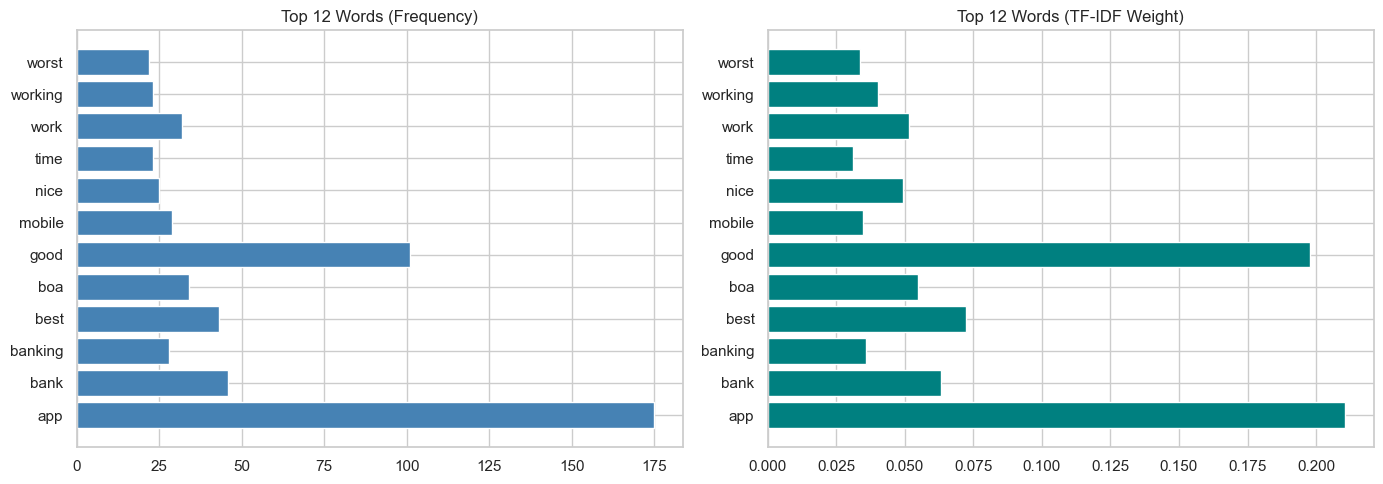

In [27]:
# Frequency (BoW) vs TF-IDF
tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(df_clean['clean_text'])

cv_vec = CountVectorizer(max_features=12, stop_words='english')
X_cv = cv_vec.fit_transform(df_clean['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cv_vec.get_feature_names_out(), X_cv.toarray().sum(axis=0), color='steelblue')
axes[0].set_title('Top 12 Words (Frequency)')

axes[1].barh(tfidf_vec.get_feature_names_out(), X_tfidf.toarray().mean(axis=0), color='teal')
axes[1].set_title('Top 12 Words (TF-IDF Weight)')

plt.tight_layout(); plt.show()

## N-gram Analysis


C:\Users\dagic\AppData\Local\Temp\ipykernel_5848\40103568.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
C:\Users\dagic\AppData\Local\Temp\ipykernel_5848\40103568.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')


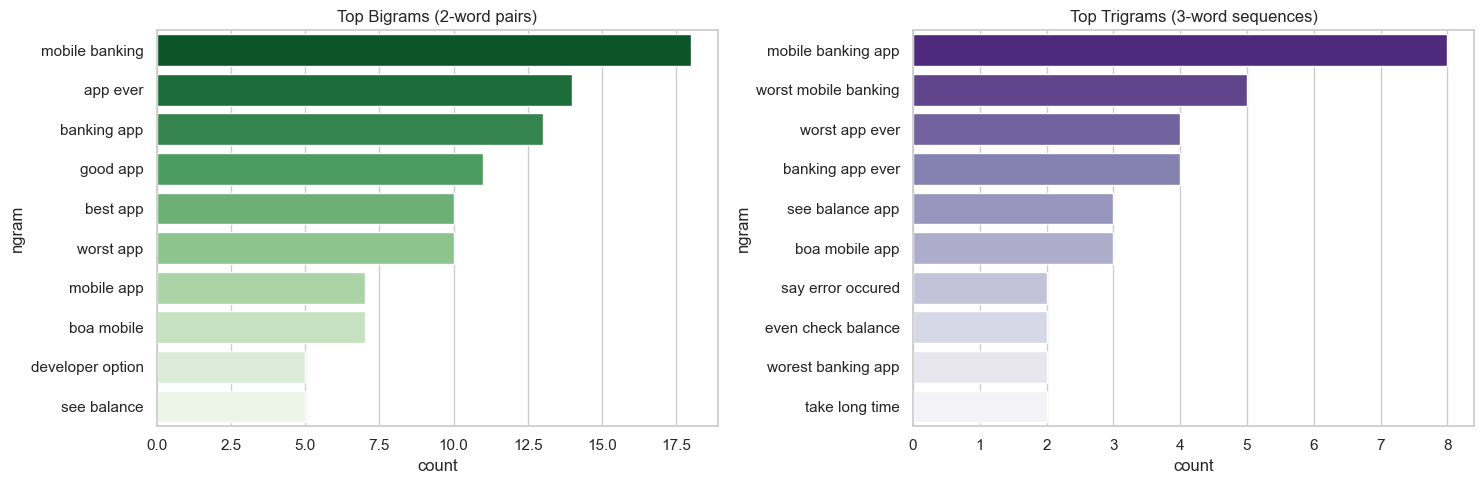

In [28]:
def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

bi = get_top_ngrams(df_clean['clean_text'], 2)
tri = get_top_ngrams(df_clean['clean_text'], 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

## POS Tagging and Noun Extraction

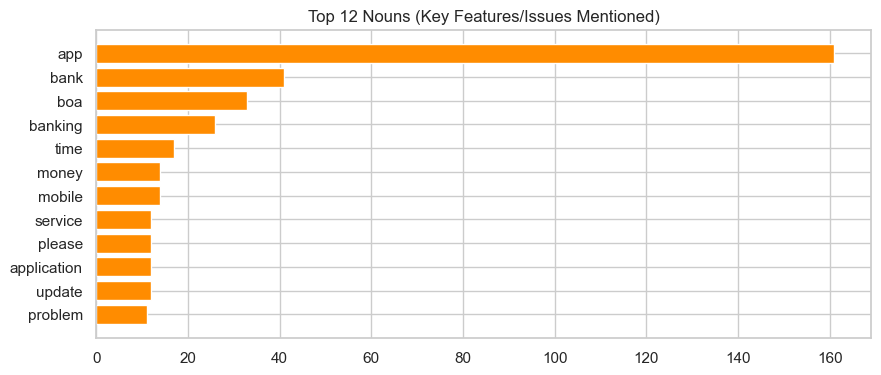

In [29]:
# Identifying Product Features (Nouns)
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

# Download the specific tagger if it's not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

df_clean['nouns'] = df_clean['review'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

## Word Cloud

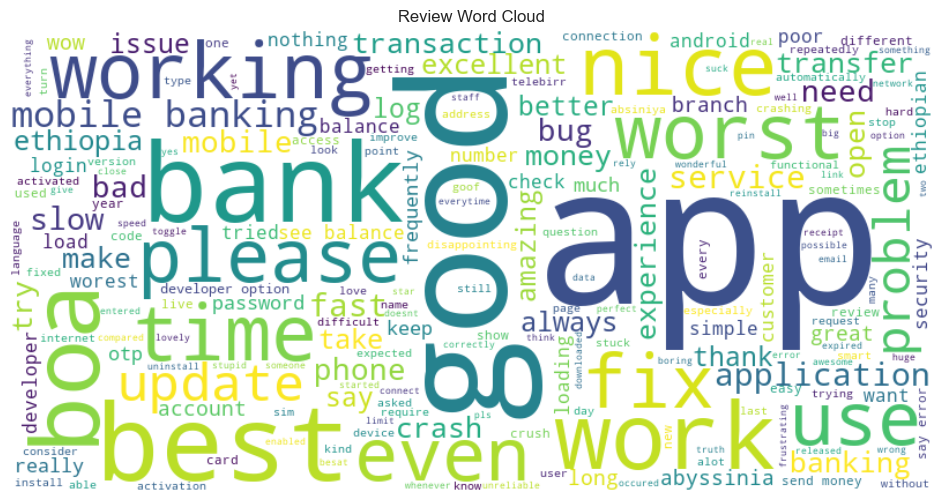

In [30]:
# Cell 8: Word Cloud
text_combined = " ".join(df_clean['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()

## Multi-Model Sentiment Analysis

In [31]:
# Sentiment Application
df_clean['vader_compound'] = df_clean['review'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_clean['tb_polarity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_clean['tb_subjectivity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

def get_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df_clean['sentiment'] = df_clean['vader_compound'].apply(get_label)
print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))

VADER Distribution:
 sentiment
positive    0.54
neutral     0.27
negative    0.19
Name: proportion, dtype: float64


#### Interpretation
    The Vader distrubition showed that:
        - 54% of the total review are positive
        - 27% is neutral
        - 19% is negative
    ** nearly half of the review are not positive, this shows the users are highly dissatisfied